In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

class SmartLinearRegression:
    def __init__(self):
        self.model = None
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        self.poly_features = None
        self.feature_names = []
        self.target_name = ""
        self.best_params = {}
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.data = None
        self.use_feature_scaling = False
        self.use_target_scaling = False
    
    def load_data(self, file_path):
        """Load CSV data"""
        try:
            self.data = pd.read_csv(file_path)
            print(f"Data loaded successfully: {self.data.shape}")
            print(f"Columns: {self.data.columns.tolist()}")
            return self.data
        except Exception as e:
            print(f"Error loading data: {e}")
            return None
    
    def show_data_info(self):
        """Display data information"""
        if self.data is not None:
            print("\nDATA INFORMATION")
            print("=" * 50)
            print(self.data.info())
            print("\nDESCRIPTIVE STATISTICS")
            print("=" * 50)
            print(self.data.describe())
            print("\nFIRST 5 ROWS")
            print("=" * 50)
            print(self.data.head())
        else:
            print("No data loaded yet!")
    
    def prepare_features(self, target_col, feature_cols, test_size=0.2):
        """Prepare features and target variables"""
        self.target_name = target_col
        self.feature_names = feature_cols
        
        missing_cols = [col for col in [target_col] + feature_cols if col not in self.data.columns]
        if missing_cols:
            print(f"Missing columns: {missing_cols}")
            return False
        
        X = self.data[feature_cols].copy()
        y = self.data[target_col].copy()
        
        print("🔧 Handling missing values...")
        X = X.fillna(X.mean())
        y = y.fillna(y.mean())
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        
        print(f"Data prepared: Train {self.X_train.shape}, Test {self.X_test.shape}")
        return True
    
    def quick_train(self, use_target_scaling=True):
        self.use_target_scaling = use_target_scaling
        
        X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = self._scale_data(
            self.X_train, self.X_test, self.y_train, self.y_test, 
            feature_scaling=False, target_scaling=use_target_scaling
        )
        
        self.model = LinearRegression()
        self.model.fit(X_train_scaled, y_train_scaled)
        
        y_pred_train_scaled = self.model.predict(X_train_scaled)
        y_pred_test_scaled = self.model.predict(X_test_scaled)
        
        if use_target_scaling:
            y_pred_train = self.target_scaler.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()
            y_pred_test = self.target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
        else:
            y_pred_train = y_pred_train_scaled
            y_pred_test = y_pred_test_scaled
        
        return self._calculate_metrics(self.y_train, y_pred_train, self.y_test, y_pred_test)
    
    def auto_tune(self, use_target_scaling=True):
        self.use_target_scaling = use_target_scaling
        
        X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = self._scale_data(
            self.X_train, self.X_test, self.y_train, self.y_test, 
            feature_scaling=False, target_scaling=use_target_scaling
        )
        
        models_params = {
            'linear': {
                'model': LinearRegression(),
                'params': {}
            },
            'ridge': {
                'model': Ridge(),
                'params': {'alpha': [0.1, 1.0, 10.0, 100.0]}
            },
            'lasso': {
                'model': Lasso(),
                'params': {'alpha': [0.1, 1.0, 10.0, 100.0]}
            }
        }
        
        best_score = -np.inf
        best_model = None
        best_model_name = ""
        
        for name, config in models_params.items():
            model = config['model']
            params = config['params']
            
            if params:
                grid_search = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
                grid_search.fit(X_train_scaled, y_train_scaled)
                score = grid_search.best_score_
                current_model = grid_search.best_estimator_
                print(f"{name.upper()}: R² = {score:.4f}, Params: {grid_search.best_params_}")
            else:
                score = np.mean(cross_val_score(model, X_train_scaled, y_train_scaled, cv=5, scoring='r2'))
                current_model = model.fit(X_train_scaled, y_train_scaled)
                print(f"{name.upper()}: R² = {score:.4f}")
            
            if score > best_score:
                best_score = score
                best_model = current_model
                best_model_name = name
        
        self.model = best_model
        print(f"Best model: {best_model_name.upper()} with R² = {best_score:.4f}")
        
        y_pred_train_scaled = self.model.predict(X_train_scaled)
        y_pred_test_scaled = self.model.predict(X_test_scaled)
        
        if use_target_scaling:
            y_pred_train = self.target_scaler.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()
            y_pred_test = self.target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
        else:
            y_pred_train = y_pred_train_scaled
            y_pred_test = y_pred_test_scaled
        
        return self._calculate_metrics(self.y_train, y_pred_train, self.y_test, y_pred_test)
    
    def manual_tune(self, reg_type='none', alpha=1.0, poly_degree=1, feature_scaling=True, target_scaling=True):
        print(f"Manual tuning: {reg_type}, alpha={alpha}, poly_degree={poly_degree}")
        print(f"Feature scaling: {feature_scaling}, Target scaling: {target_scaling}")
        
        self.use_feature_scaling = feature_scaling
        self.use_target_scaling = target_scaling
        
        X_train_processed = self.X_train.copy()
        X_test_processed = self.X_test.copy()
        
        if poly_degree > 1:
            print(f"Applying polynomial features (degree={poly_degree})...")
            self.poly_features = PolynomialFeatures(degree=poly_degree, include_bias=False)
            X_train_processed = self.poly_features.fit_transform(X_train_processed)
            X_test_processed = self.poly_features.transform(X_test_processed)
        
        if feature_scaling:
            print("Scaling features (fit on training data only)...")
            X_train_processed = self.feature_scaler.fit_transform(X_train_processed)
            X_test_processed = self.feature_scaler.transform(X_test_processed)
        
        if target_scaling:
            print("Scaling target (fit on training data only)...")
            y_train_scaled = self.target_scaler.fit_transform(self.y_train.values.reshape(-1, 1)).flatten()
            y_test_scaled = self.target_scaler.transform(self.y_test.values.reshape(-1, 1)).flatten()
        else:
            y_train_scaled = self.y_train
            y_test_scaled = self.y_test
        
        if reg_type == 'ridge':
            self.model = Ridge(alpha=alpha)
        elif reg_type == 'lasso':
            self.model = Lasso(alpha=alpha)
        else:
            self.model = LinearRegression()
        
        self.model.fit(X_train_processed, y_train_scaled)
        
        y_pred_train_scaled = self.model.predict(X_train_processed)
        y_pred_test_scaled = self.model.predict(X_test_processed)
        
        if target_scaling:
            y_pred_train = self.target_scaler.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).flatten()
            y_pred_test = self.target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
        else:
            y_pred_train = y_pred_train_scaled
            y_pred_test = y_pred_test_scaled
        
        print("\nAll metrics reported on ORIGINAL scale:")
        return self._calculate_metrics(self.y_train, y_pred_train, self.y_test, y_pred_test)
    
    def _scale_data(self, X_train, X_test, y_train, y_test, feature_scaling=True, target_scaling=True):
        """Scale data using scalers fitted ONLY on training data"""
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        
        if feature_scaling:
            X_train_scaled = self.feature_scaler.fit_transform(X_train)
            X_test_scaled = self.feature_scaler.transform(X_test)
        
        if target_scaling:
            y_train_scaled = self.target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
            y_test_scaled = self.target_scaler.transform(y_test.values.reshape(-1, 1)).flatten()
        else:
            y_train_scaled = y_train
            y_test_scaled = y_test
        
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled
    
    def _calculate_metrics(self, y_train, y_pred_train, y_test, y_pred_test):
        """Calculate comprehensive metrics"""
        metrics = {
            'train_r2': r2_score(y_train, y_pred_train),
            'test_r2': r2_score(y_test, y_pred_test),
            'train_rmse': sqrt(mean_squared_error(y_train, y_pred_train)),
            'test_rmse': sqrt(mean_squared_error(y_test, y_pred_test)),
            'train_mae': mean_absolute_error(y_train, y_pred_train),
            'test_mae': mean_absolute_error(y_test, y_pred_test),
            'y_test': y_test.values if hasattr(y_test, 'values') else y_test,
            'y_pred_test': y_pred_test,
            'y_train': y_train.values if hasattr(y_train, 'values') else y_train,
            'y_pred_train': y_pred_train
        }
        
        r2_diff = metrics['train_r2'] - metrics['test_r2']
        if r2_diff > 0.1:
            overfitting_status = "Potential Overfitting"
        elif r2_diff < -0.05:
            overfitting_status = "Potential Underfitting"
        else:
            overfitting_status = "Good Fit"
        
        metrics['overfitting_status'] = overfitting_status
        
        print("\n📈 MODEL PERFORMANCE REPORT")
        print("=" * 50)
        print(f"Train R²: {metrics['train_r2']:.4f}")
        print(f"Test R²:  {metrics['test_r2']:.4f}")
        print(f"Train RMSE: {metrics['train_rmse']:.4f}")
        print(f"Test RMSE:  {metrics['test_rmse']:.4f}")
        print(f"Train MAE: {metrics['train_mae']:.4f}")
        print(f"Test MAE:  {metrics['test_mae']:.4f}")
        print(f"Status: {overfitting_status}")
        print("=" * 50)
        
        return metrics
    
    def cross_validation_analysis(self, cv_folds=5):
        """Perform cross-validation analysis"""
        print(f"\nPerforming {cv_folds}-fold Cross Validation...")
        
        X_train_processed = self.X_train.copy()
        y_train_processed = self.y_train.copy()
        
        if self.poly_features is not None:
            X_train_processed = self.poly_features.transform(X_train_processed)
        
        if self.use_feature_scaling:
            X_train_processed = self.feature_scaler.transform(X_train_processed)
        
        if self.use_target_scaling:
            y_train_processed = self.target_scaler.transform(y_train_processed.values.reshape(-1, 1)).flatten()
        
        cv_r2_scores = cross_val_score(self.model, X_train_processed, y_train_processed, cv=cv_folds, scoring='r2')
        cv_rmse_scores = -cross_val_score(self.model, X_train_processed, y_train_processed, cv=cv_folds, scoring='neg_root_mean_squared_error')
        
        cv_results = {
            'r2_mean': cv_r2_scores.mean(),
            'r2_std': cv_r2_scores.std(),
            'rmse_mean': cv_rmse_scores.mean(),
            'rmse_std': cv_rmse_scores.std(),
            'r2_scores': cv_r2_scores,
            'rmse_scores': cv_rmse_scores
        }
        
        print(f"Cross-Validation R² : {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
        print(f"Cross-Validation RMSE: {cv_results['rmse_mean']:.4f} ± {cv_results['rmse_std']:.4f}")
        
        return cv_results
    
    def plot_results(self):
        """Plot actual vs predicted values"""
        fig, ax = plt.subplots(1, 1, figsize=(10, 8
                                              ))
        
        X_test_processed = self._preprocess_for_prediction(self.X_test)
        y_pred_test_scaled = self.model.predict(X_test_processed)
        
        if self.use_target_scaling:
            y_pred_test = self.target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
        else:
            y_pred_test = y_pred_test_scaled
        
        test_r2 = r2_score(self.y_test, y_pred_test)
        test_rmse = sqrt(mean_squared_error(self.y_test, y_pred_test))
        
        ax.scatter(self.y_test, y_pred_test, alpha=0.7, color='blue', label='Predictions')
        ax.plot([self.y_test.min(), self.y_test.max()], [self.y_test.min(), self.y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        ax.set_xlabel('Actual CCG Yield')
        ax.set_ylabel('Predicted CCG Yield')
        ax.set_title(f'Actual vs Predicted\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_feature_analysis(self, feature_name):
        """Plot feature vs target with predictions"""
        if feature_name not in self.feature_names:
            print(f"❌ Feature '{feature_name}' not found in selected features")
            print(f"Available features: {self.feature_names}")
            return
        
        feature_idx = self.feature_names.index(feature_name)
        
        X_test_processed = self._preprocess_for_prediction(self.X_test)
        y_pred_test_scaled = self.model.predict(X_test_processed)
        
        if self.use_target_scaling:
            y_pred_test = self.target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()
        else:
            y_pred_test = y_pred_test_scaled
        
        plt.figure(figsize=(10, 6))
        
        plt.scatter(self.X_test.iloc[:, feature_idx], self.y_test, alpha=0.6, label='Actual', color='blue', s=50)
        plt.scatter(self.X_test.iloc[:, feature_idx], y_pred_test, alpha=0.6, label='Predicted', color='red', s=50)
        
        plt.xlabel(f'{feature_name} (Original Scale)')
        plt.ylabel(f'{self.target_name} (Original Scale)')
        plt.title(f'{feature_name} vs {self.target_name}\nActual vs Predicted')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    def _preprocess_for_prediction(self, X):
        """Preprocess features for prediction using SAME scalers fitted on training data"""
        X_processed = X.copy()
        
        if self.poly_features is not None:
            X_processed = self.poly_features.transform(X_processed)
        
        if self.use_feature_scaling:
            X_processed = self.feature_scaler.transform(X_processed)
        
        return X_processed
    
    def predict_single(self, input_values):
        """Make prediction for single input - returns value on ORIGINAL scale"""
        try:
            if isinstance(input_values, dict):
                input_list = [input_values[feature] for feature in self.feature_names]
            else:
                input_list = input_values
            
            input_df = pd.DataFrame([input_list], columns=self.feature_names)
            
            input_processed = self._preprocess_for_prediction(input_df)
            
            prediction_scaled = self.model.predict(input_processed)[0]
            
            if self.use_target_scaling:
                prediction = self.target_scaler.inverse_transform([[prediction_scaled]])[0][0]
            else:
                prediction = prediction_scaled
            
            print(f"\n PREDICTION RESULT (Original Scale)")
            print(f"Input: {dict(zip(self.feature_names, input_list))}")
            print(f"Predicted {self.target_name}: {prediction:.4f}")
            
            return prediction
        except Exception as e:
            print(f"Prediction error: {e}")
            return None

Data loaded successfully: (1836, 12)
Columns: ['CCG Yield', 'Feed Temp', 'C/O Ratio', 'Reactor temp', 'Feed flow', 'Stab ovhd temp', 'Dense phase temp', 'UOPK', 'Total arom', 'Feed FBP', 'Feed density', 'CCG FBP']
🔧 Handling missing values...
✅ Data prepared: Train (1468, 7), Test (368, 7)

📈 MODEL PERFORMANCE REPORT
Train R²: 0.7202
Test R²:  0.7163
Train RMSE: 0.5921
Test RMSE:  0.5699
Train MAE: 0.4661
Test MAE:  0.4542
Status: ✅ Good Fit

🔄 Performing 5-fold Cross Validation...
Cross-Validation R² : 0.7175 ± 0.0131
Cross-Validation RMSE: 0.5306 ± 0.0147


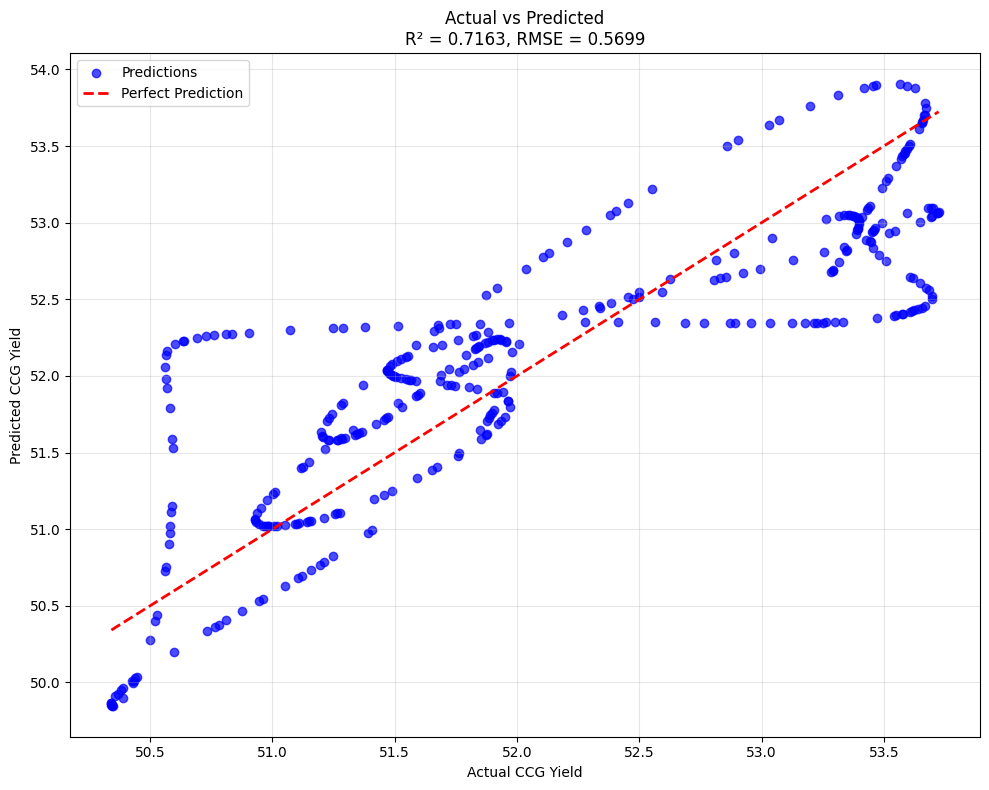

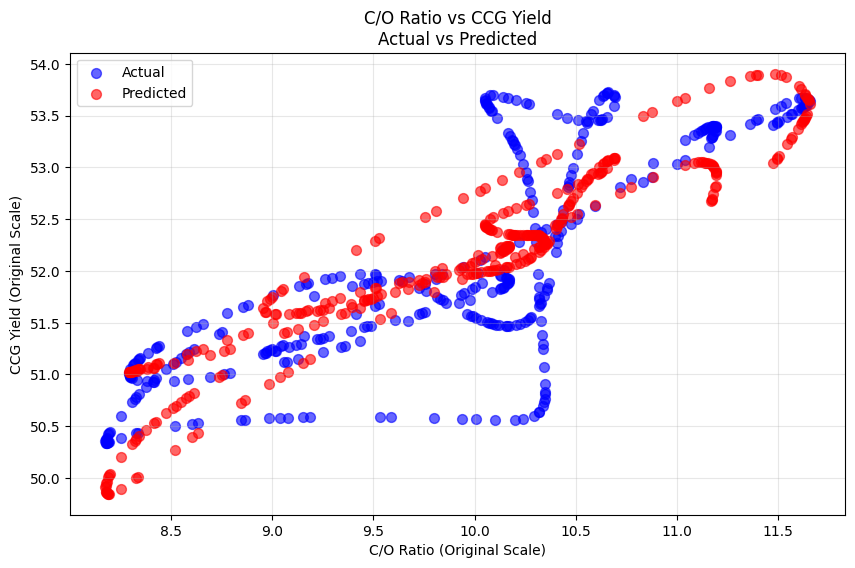

In [ ]:
# 1. Create model instance
model = SmartLinearRegression()

# 2. Load data
dataset_path = r'D:\python-workspace\.venv\Notebooks\Gaussian_denoised50_final.csv'
model.load_data(dataset_path)

# 3. Prepare features 
model.prepare_features('CCG Yield',
                        ['Feed Temp', 'C/O Ratio', 'Reactor temp', 'Feed flow', 'Stab ovhd temp', 'Dense phase temp', 'CCG FBP'])

# 4. Train model 
model.quick_train() 

# model.auto_tune()            # Auto finds best model
 
# model.manual_tune('ridge', alpha=100, poly_degree=3, feature_scaling=True, target_scaling=True)

# 5. Cross-validation analysis
model.cross_validation_analysis()

# 6. Plot results (shows R² and RMSE)
model.plot_results()

# 7. Feature analysis plot
model.plot_feature_analysis('C/O Ratio')  

In [3]:
prediction = model.predict_single({
'Feed Temp':200,
'C/O Ratio':10,
'OVHD Temp':125,
'Reactor temp':509,
'Feed flow':800,
'Stab ovhd temp':54,
'Dense phase temp':645,
'UOPK':12,
'CCG FBP': 200
    })
# print(f'Prediction: {prediction}')


🎯 PREDICTION RESULT (Original Scale)
Input: {'Feed Temp': 200, 'C/O Ratio': 10, 'Reactor temp': 509, 'Feed flow': 800, 'Stab ovhd temp': 54, 'Dense phase temp': 645, 'CCG FBP': 200}
Predicted CCG Yield: 51.9152


In [4]:
import pickle
# Save the model
model_package = {
    'model': model.model,           # The actual trained model (SVR, etc.)
    'feature_scaler': model.feature_scaler,     # Feature scaler
    'target_scaler': model.target_scaler      # Target scaler
}

# Save as new file
with open('mlr_model_package.pkl', 'wb') as f:
    pickle.dump(model_package, f)